<a href="https://colab.research.google.com/github/nabussel/shape-detection-geometry-ai/blob/main/Copy_of_DetermineShape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt


def generate_random_ellipse_points(num_points, rad_a, rad_b, noise, center_x=0, center_y=0, angle=0):
    '''
    Generate random points of an ellipse with noise

    Args:
    num_points (int): Number of points to generate
    rad_a (float): Vertical axis radius
    rad_b (float): Horizontal axis radius
    noise (float): Desired noise of the ellipse points
    center_x (float): x-coordinate of the center of the ellipse
    center_y (float): y-coordinate of the center of the ellipse
    angle (float): Rotation angle of the ellipse in radians

    Returns:
    coordinates (list): List of (x, y) coordinates of the generated ellipse points without noise
    coordinates_noisy (list): List of (x, y) coordinates of the noisy ellipse points
    '''
    coordinates = []
    coordinates_noisy = []

    # Generate points on the ellipse and apply noise
    for i in range(num_points):
        theta = 2 * math.pi * i / num_points
        x = rad_a * math.cos(theta) + center_x  # Apply center offset to x
        y = rad_b * math.sin(theta) + center_y  # Apply center offset to y

        noise_x = random.uniform(-rad_a * noise, rad_a * noise)
        noise_y = random.uniform(-rad_b * noise, rad_b * noise)

        noisy_x = x + noise_x
        noisy_y = y + noise_y

        coordinates.append((x, y))
        coordinates_noisy.append((noisy_x, noisy_y))
    angle = np.radians(angle)
    # Now apply rotation to noisy points around the center
    coordinates_noisy_rotated = []
    for x, y in coordinates_noisy:
        # Translate the point to origin (subtract center), rotate, then translate back
        x_rel = x - center_x
        y_rel = y - center_y


        rotated_x = x_rel * np.cos(angle) - y_rel * np.sin(angle) + center_x
        rotated_y = x_rel * np.sin(angle) + y_rel * np.cos(angle) + center_y

        coordinates_noisy_rotated.append((rotated_x, rotated_y))

    return coordinates, coordinates_noisy_rotated





from scipy.optimize import minimize
# Function to calculate the distance from a point (px, py) to the ellipse
def closest_distance_to_ellipse(px, py, rad_a, rad_b):
  '''
  Find the smallest distance from a point (px, py) to the ellipse that is axis aligned and centered with the origin

  Args:
  px (float): x-coordinate of the point
  py (float): y-coordinate of the point
  rad_a (float): Vertical axis radius
  rad_b (float): Horizontal axis radius

  Returns:
  float: The distance from the point (px, py) to the closest point on the ellipse
  '''
    # Objective function to minimize (distance from (px, py) to ellipse)
    def objective(theta):
      '''
      Generate

      '''
        ellipse_x = rad_a * math.cos(theta)
        ellipse_y = rad_b * math.sin(theta)
        return (px - ellipse_x)**2 + (py - ellipse_y)**2
    initial_guess = math.atan2(py,px)
    # Minimize the objective function to find the closest point on the ellipse
    result = minimize(objective, initial_guess)  # Start the search from angle 0
    closest_theta = result.x[0]  # The angle of the closest point
    closest_x = rad_a * math.cos(closest_theta)
    closest_y = rad_b * math.sin(closest_theta)

    # Return the distance between the point (px, py) and the closest point on the ellipse
    return math.sqrt((px - closest_x)**2 + (py - closest_y)**2)




# Function to fit an ellipse to noisy points (using the algorithm by Halir and Flusser)
def fit_ellipse(x, y):
    D1 = np.vstack([x**2, x*y, y**2]).T
    D2 = np.vstack([x, y, np.ones(len(x))]).T
    S1 = D1.T @ D1
    S2 = D1.T @ D2
    S3 = D2.T @ D2
    T = -np.linalg.inv(S3) @ S2.T
    M = S1 + S2 @ T
    C = np.array(((0, 0, 2), (0, -1, 0), (2, 0, 0)), dtype=float)
    M = np.linalg.inv(C) @ M
    eigval, eigvec = np.linalg.eig(M)
    con = 4 * eigvec[0]* eigvec[2] - eigvec[1]**2
    ak = eigvec[:, np.nonzero(con > 0)[0]]
    return np.concatenate((ak, T @ ak)).ravel()


# Convert cartesian coefficients to ellipse parameters
def cart_to_pol(coeffs):
    a = coeffs[0]
    b = coeffs[1] / 2
    c = coeffs[2]
    d = coeffs[3] / 2
    f = coeffs[4] / 2
    g = coeffs[5]

    den = b**2 - a*c
    if den > 0:
        raise ValueError('coeffs do not represent an ellipse: b^2 - 4ac must'
                         ' be negative!')

    # The location of the ellipse centre.
    x0, y0 = (c*d - b*f) / den, (a*f - b*d) / den

    num = 2 * (a*f**2 + c*d**2 + g*b**2 - 2*b*d*f - a*c*g)
    fac = np.sqrt((a - c)**2 + 4*b**2)
    # The semi-major and semi-minor axis lengths (these are not sorted).
    ap = np.sqrt(num / den / (fac - a - c))
    bp = np.sqrt(num / den / (-fac - a - c))

    # Sort the semi-major and semi-minor axis lengths but keep track of
    # the original relative magnitudes of width and height.
    width_gt_height = True
    if ap < bp:
        width_gt_height = False
        ap, bp = bp, ap

    # The eccentricity.
    r = (bp/ap)**2
    if r > 1:
        r = 1/r
    e = np.sqrt(1 - r)

    # The angle of anticlockwise rotation of the major-axis from x-axis.
    if b == 0:
        phi = 0 if a < c else np.pi/2
    else:
        phi = np.arctan((2.*b) / (a - c)) / 2
        if a > c:
            phi += np.pi/2
    if not width_gt_height:
        # Ensure that phi is the angle to rotate to the semi-major axis.
        phi += np.pi/2
    phi = phi % np.pi

    return x0, y0, ap, bp, e, phi


# Function to generate points on an ellipse based on the ellipse parameters
def get_ellipse_pts(params, npts=100, tmin=0, tmax=2*np.pi):
    x0, y0, ap, bp, e, phi = params
    t = np.linspace(tmin, tmax, npts)
    x = x0 + ap * np.cos(t) * np.cos(phi) - bp * np.sin(t) * np.sin(phi)
    y = y0 + ap * np.cos(t) * np.sin(phi) + bp * np.sin(t) * np.cos(phi)
    return x, y




Code for finding the dimensions of the fitted square/circle

In [ ]:

import seaborn as sns


def distance_to_radius(point, radius):
      """
    Compute the shortest distance from a 2D point to the circumference
    of a circle centered at the origin.

    The function projects the point onto the direction defined by its
    angle from the origin (theta), determines the corresponding point
    on the circle of the given radius in that direction, and returns
    the Euclidean distance between the two.

    Args:
        point (tuple[float, float]): The (x, y) coordinates of the point.
        radius (float): The radius of the circle centered at (0, 0).

    Returns:
        float: The shortest distance from the point to the circle's
               circumference.
    """
    x, y = point
    theta = math.atan2(y, x)

    radius_point_x = radius * math.cos(theta)
    radius_point_y = radius * math.sin(theta)

    return math.sqrt((x - radius_point_x)**2 + (y - radius_point_y)**2)

def find_radius_range(noisy_points):
    """
    Compute the minimum and maximum radial distances of a set of 2D points
    from the origin.

    For each point (x, y), the Euclidean distance to the origin is calculated.
    The function then returns the smallest and largest of these distances,
    which together describe the radial range of the point set. This is
    particularly useful for noisy data sampled around a circle or ellipse
    to estimate the spread in radius.

    Args:
        A list of (x, y) coordinate pairs representing points in 2D.

    Returns:
        A pair (min_distance, max_distance), where
            - min_distance is the closest point's distance to the origin
            - max_distance is the farthest point's distance to the origin
    """
    max_distance = 0
    min_distance = float('inf')
    for x,y in noisy_points:
        distance = math.sqrt(x**2 + y**2)
        if distance > max_distance:
            max_distance = distance
        if distance < min_distance:
            min_distance = distance
    return min_distance, max_distance



def circle_ridge(noisy_points,alpha):
    """
    Estimate the best-fitting circle radius for a set of noisy 2D points
    using a ridge-style regularization approach.

    The function searches over a range of radii between the minimum and
    maximum distances of the points from the origin. For each candidate
    radius, it computes an objective function ("ridge_sum") that combines:
        1. The total distance of all points to the circle of that radius
        2. A penalty term proportional to the square of the radius
           (scaled by alpha)

    The radius that minimizes this ridge_sum is chosen as the "best" radius.

    Args:
            A list of (x, y) coordinates representing noisy samples around
            an approximate circle centered at the origin.
        alpha (float):
            Regularization strength; higher values penalize larger radii more
            heavily, preventing overfitting to outliers.

    Returns:
            - best_radius (float): The radius value that minimizes the ridge_sum.
            - best_score (float): The corresponding ridge_sum value at best_radius.
  """
  min_radius, max_radius = find_radius_range(noisy_points)

  smallest_radius = float('inf')
  smallest_sum = float('inf')
  while min_radius < max_radius:
    ridge_sum = 0

    for x,y in noisy_points:
      ridge_sum += distance_to_radius((x,y),min_radius) + alpha * (min_radius**2)


    if ridge_sum < smallest_sum:
      smallest_radius = min_radius
      smallest_sum = ridge_sum

    min_radius += .001
  return smallest_radius, smallest_sum


def plot_circle(radius, x_noise, y_noise):
    """
    Plot a circle of a given radius centered at the origin, along with noisy data points.

    The function generates 100 points around the circumference of a circle
    parameterized by angle θ, and plots both the circle and the noisy
    (x, y) points provided by the user. The aspect ratio is set to equal
    so that the circle is not visually distorted.

    Args:
        radius (float):
            Radius of the circle to be drawn, centered at (0, 0).
        x_noise (array-like):
            x-coordinates of noisy sample points to be displayed as scatter.
        y_noise (array-like):
            y-coordinates of noisy sample points to be displayed as scatter.

    Returns:
        None. Displays a matplotlib figure containing:
            - The noisy points as scatter markers.
            - The fitted circle as a line plot.
    """
    theta = np.linspace(0, 2 * np.pi, 100)

    x = radius * np.cos(theta)
    y = radius * np.sin(theta)


    plt.gca().set_aspect('equal', adjustable='box')
    plt.figure(figsize = (radius+2, radius + 2))
    plt.scatter(x_noise, y_noise, marker='o')
    plt.plot(x, y)


def total_residual(length, points):
    """
    Compute the total residual (sum of distances) from a set of 2D points
    to the boundary of an axis-aligned square centered at the origin.

    For each point, the function determines whether it lies:
        - Above, below, left, or right of the square (edge cases),
        - In one of the four outer corners (diagonal cases),
        - Or inside the square.

    The residual is then computed as:
        - Vertical/Horizontal distance to the closest edge if the point is
          outside but aligned with a face.
        - Euclidean distance to the nearest corner if the point is outside
          a diagonal corner region.
        - Minimum distance to the nearest edge if the point lies inside
          the square.

    Args:
        length (float):
            Side length of the square, centered at (0, 0).
        points:
            A list of (x, y) coordinates representing the points whose
            distances to the square boundary are to be computed.

    Returns:
        float: The total residual, the sum of all point-to-square
               boundary distances.
    """
  x1 = -length/2
  x2 = length/2
  y1 = -length/2
  y2 = length/2
  residual = 0
  for x,y in points:
    if (y >= y2) and (x1<=x<=x2):
      residual += abs(y-y2)
    elif (y <= y1) and (x1<=x<=x2):
      residual += abs(y1-y)
    elif (x >= x2) and (y1<=y<=y2):
      residual += abs(x-x2)
    elif (x <= x1) and (y1<=y<=y2):
      residual += abs(x1-x)
    elif (x<=x1) and (y>=y2):
      residual += math.sqrt((x-x1)**2 + (y-y2)**2)
    elif (x>=x2) and (y>=y2):
      residual += math.sqrt((x-x2)**2 + (y-y2)**2)
    elif (x<=x1) and (y<=y1):
      residual += math.sqrt((x-x1)**2 + (y-y1)**2)
    elif (x>=x2) and (y<=y1):
      residual += math.sqrt((x-x2)**2 + (y-y1)**2)
    else:
      residual += min(abs(x-x1),abs(x-x2),abs(y-y1),abs(y-y2))
  return residual



def best_rotated_square(points):
  """
  Given a set of data points, the algorithm will fit a square to
  the data through fitting a circle to the data, and using the optimal
  radius to length ratio (0.56985955 -- found after some data analysis |
  in a separate R file) determining the length and then the rotation

  Args:
    points: A list of (x, y) coordinates representing the data points.

  Returns:
    best_angle (float): angle of rotation the fitted square is (degrees)
    length (float): the length of the fitted square
    smallest_error (float): the smallest residual of the fitted square

  """
  noise_x = [x for x,y in points]
  noise_y = [y for x,y in points]
  noise_x = np.array(noise_x)
  noise_y = np.array(noise_y)
  coordinates_noisy = list(zip(noise_x, noise_y))
  radius_ridge, smallest_ridge= circle_ridge(coordinates_noisy,0)
  length = radius_ridge/0.56985955

  smallest_error = float('inf')
  best_angle = 0
  angle = 0
  error = []
  while angle <360:
    rotated = []
    angle_use = np.radians(angle)
    cos_angle = np.cos(angle_use)
    sin_angle = np.sin(angle_use)
    rotated.extend(list(zip(cos_angle * noise_x - sin_angle * noise_y, sin_angle * noise_x + cos_angle * noise_y)))
    residual = total_residual(length, rotated)
    error.append(residual)
    if residual < smallest_error:
      smallest_error = residual
      best_angle = angle
    angle += .1
  angle = 90-best_angle
  # print(rotated)
  half_size = length / 2
  square_points = np.array([[-half_size, -half_size],
                              [half_size, -half_size],
                              [half_size, half_size],
                              [-half_size, half_size],
                              [-half_size, -half_size]])  # Close the square

    # Step 2: Rotate the square by the given number of degrees
    # Convert degrees to radians
  angle_rad = np.radians(angle)

    # Rotation matrix for 2D points
  rotation_matrix = np.array([[np.cos(angle_rad), -np.sin(angle_rad)],
                                [np.sin(angle_rad), np.cos(angle_rad)]])

    # Apply the rotation to each point
  rotated_points = np.dot(square_points[:, :2], rotation_matrix.T)
  # plt.plot(rotated_points[:, 0], rotated_points[:, 1])
  return best_angle,length, smallest_error


Code for a rectangle

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import sklearn.decomposition as skl
from sklearn.decomposition import PCA

def generate_random_rectangle_with_noise(num_points, noise_level, width, height, center_x=0, center_y=0,tha=0):
    '''
    Generate random points on a rectangle with noise.

    Args:
        num_points (int): Number of points to generate.
        noise_level (float): desired amount of noise.
        width (float): Width of the rectangle.
        height (float): Height of the rectangle.
        center_x (float, optional): x-coordinate of the center of the rectangle. Defaults to 0.
        center_y (float, optional): y-coordinate of the center of the rectangle. Defaults to 0.
        tha (float, optional): Rotation angle in degrees. Defaults to 0.

    Returns:
        noise_x (list): List of x-coordinates of the generated rectangle with noise.
        noise_y (list): List of y-coordinates of the generated rectangle with noise.
    '''

    # Calculate the corners based on the desired center
    x_min = center_x - width / 2
    y_min = center_y - height / 2

    corners = np.array([[x_min, y_min],
                        [x_min + width, y_min],
                        [x_min + width, y_min + height],
                        [x_min, y_min + height]])

    points = []
    x_bottom = np.linspace(x_min, x_min + width, math.floor(num_points* (width/(width+height))/2))
    y_bottom = np.full_like(x_bottom, y_min)
    points.extend(list(zip(x_bottom, y_bottom)))

    x_right = np.full_like(np.linspace(y_min, y_min + height, num_points // 4), x_min + width)
    y_right = np.linspace(y_min, y_min + height, math.floor(num_points*(height/(width+height))/2))
    points.extend(list(zip(x_right, y_right)))

    x_top = np.linspace(x_min + width, x_min, math.floor(num_points*(width/(width+height))/2))
    y_top = np.full_like(x_top, y_min + height)
    points.extend(list(zip(x_top, y_top)))

    x_left = np.full_like(np.linspace(y_min + height, y_min, num_points // 4), x_min)
    y_left = np.linspace(y_min + height, y_min, math.floor(num_points*(height/(width+height))/2))
    points.extend(list(zip(x_left, y_left)))

    # Add noise to the points
    noisy_x = []
    noisy_y = []
    for point in points:
        x, y = point
        noisy_x.append(x + np.random.uniform(-noise_level, noise_level))
        noisy_y.append(y + np.random.uniform(-noise_level, noise_level))

    # Rotation (if any)
    angle = np.radians(tha)
    cos_angle = np.cos(angle)
    sin_angle = np.sin(angle)
    noisy_x = np.array(noisy_x)
    noisy_y = np.array(noisy_y)

    new_points = []
    new_points.extend(list(zip(cos_angle * noisy_x - sin_angle * noisy_y,
                               sin_angle * noisy_x + cos_angle * noisy_y)))

    # No additional shifting is needed here
    noise_x = [round(x, 2) for x, y in new_points]
    noise_y = [round(y, 2) for x, y in new_points]

    # Plot the points for visualization
    plt.gca().set_aspect('equal', adjustable='box')
    plt.scatter(noise_x, noise_y)
    plt.show()

    return noise_x, noise_y




def find_rectangle_corners(x_cord,y_cord):
  '''
  Given lists of the x and y coordinates of what is assumed to be a
  rectangle, this function finds the four corners of the rectangle.

  Args:
    x_cord (list): list of x coordinates
    y_cord (list): list of y coordinates

  Returns:
    min_x_point (tuple): the point with the smallest x value; the
    min_y_point (tuple): the point with the smallest y value
    max_x_point (tuple): the point with the largest x value
    max_y_point (tuple): the point with the largest y value
  '''
    points = list(zip(x_cord, y_cord))
    # Find the points with the minimum and maximum x and y values
    min_x_point = min(points, key=lambda p: p[0])  # Find point with the smallest x
    max_x_point = max(points, key=lambda p: p[0])  # Find point with the largest x
    min_y_point = min(points, key=lambda p: p[1])  # Find point with the smallest y
    max_y_point = max(points, key=lambda p: p[1])  # Find point with the largest y

    return min_x_point, min_y_point, max_x_point, max_y_point




def find_outer_rectangle(x_cord, y_cord):
  '''
  Given lists of the x and y coordinates of what is assumed to be a
  rectangle, this function finds the length and height of the rectangle that
  encapsulates all of the data.

  Args:
    x_cord (list): list of x coordinates
    y_cord (list): list of y coordinates

  Returns:
    width (float): the length of the outer rectangle
    height (float): the height of the outer rectangle
  '''
  points = list(zip(x_cord, y_cord))
  left,bottom,right,top = find_rectangle_corners(x_cord,y_cord)

  width = right[0] - left[0]
  height = top[1] - bottom[1]

    # Calculate the center of the rectangle (which is the origin for this case)
  center_x = 0
  center_y = 0

    # Calculate the four corners of the rectangle centered around the origin
  corners = [
        [left[0], top[1]],  # top-left corner
        [right[0], top[1]],  # top-right corner
        [right[0], bottom[1]],  # bottom-right corner
        [left[0], bottom[1]],  # bottom-left corner
        [left[0], top[1]]  # Closing the rectangle by returning to top-left corner
    ]

    # Unzip the corners into x and y values
  x_vals, y_vals = zip(*corners)
  # plt.gca().set_aspect('equal', adjustable='box')  # Equal aspect ratio for square plot
  # plt.plot(x_vals, y_vals, color='orange')
  # rectangle_corners = [
  #         [x_left, y_top],  # top-left corner
  #         [x_right, y_top],  # top-right corner
  #         [x_right, y_bottom],  # bottom-right corner
  #         [x_left, y_bottom],  # bottom-left corner
  #         [x_left, y_top]  # closing the rectangle by returning to the top-left corner
  #     ]
  # x_vals = [corner[0] for corner in rectangle_corners]
  # y_vals = [corner[1] for corner in rectangle_corners]
  # plt.plot(x_vals, y_vals, color = "green")



  return width, height


def find_inner_rectangle(x_cord, y_cord):
  '''
  Given lists of the x and y coordinates of what is assumed to be a
  rectangle, this function finds the length and height of the rectangle that
  the data encapsulates.

  Args:
    x_cord (list): list of x coordinates
    y_cord (list): list of y coordinates

  Returns:
    base (float): the length of the inner rectangle
    height (float): the height of the inner rectangle
  '''
  points = list(zip(x_cord, y_cord))
  smallest_distance = float('inf')
  smallest_point = None
  base, height = find_outer_rectangle(x_cord, y_cord)
  ratio = base/height
  inside = True
  while inside:
    inside = False
    for x,y in points:
      base -= 0.01
      height = base/ratio
      if (-base / 2 <= x <= base / 2) and (-height / 2 <= y <= height / 2):
        inside = True
  rectangle_corners = [
        [-base/2, height/2 ],  # top-left corner
        [base/2 , height/2 ],   # top-right corner
        [base/2 , -height/2],  # bottom-right corner
        [-base/2 , -height/2 ], # bottom-left corner
        [-base/2 , height/2 ]   # closing the rectangle by returning to the top-left corner
    ]
  x_vals = [corner[0] for corner in rectangle_corners]
  y_vals = [corner[1] for corner in rectangle_corners]
  # plt.gca().set_aspect('equal', adjustable='box')
  # plt.plot(x_vals, y_vals, color = "red")
  return base,height



def find_rotation_angle(x_cord, y_cord):
    '''
    Given lists of the x and y coordinates of what is assumed to be a
    rectangle, this function finds the rotation angle of the rectangle.

    Args:
      x_cord (list): list of x coordinates
      y_cord (list): list of y coordinates

      Returns:
      angle_deg (float): the rotation angle of the rectangle

    '''
    # Stack the coordinates into a single matrix of shape (n_points, 2)
    data = np.vstack((x_cord, y_cord)).T

    # Apply PCA to find the principal axes
    pca = PCA(n_components=2)
    pca.fit(data)

    # The angle of rotation is the angle of the first principal component with respect to the x-axis
    # PCA.components_[0] gives the direction of the first principal component
    angle = np.arctan2(pca.components_[0][1], pca.components_[0][0])

    # Convert angle from radians to degrees
    angle_deg = np.degrees(angle)

    return angle_deg

# Find the rotation angle



def total_residual_1(base, height, x_cord, y_cord):
  '''
  Given lists of the x and y coordinates of what is assumed to be a
  rectangle in addition to the base and height of a given rectangle,
  this function finds the sum of residuals of all of the points from
  the given rectangle.

  Args:
    base (float): the length of the rectangle
    height (float): the height of the rectangle
    x_cord (list): list of x coordinates
    y_cord (list): list of y coordinates

  Returns:
    residual (float): the sum of residuals
  '''
  points = list(zip(x_cord, y_cord))
  x1 = -base/2
  x2 = base/2
  y1 = -height/2
  y2 = height/2
  residual = 0
  for x,y in points:
    if (y >= y2) and (x1<=x<=x2):
      residual += abs(y-y2)
    elif (y <= y1) and (x1<=x<=x2):
      residual += abs(y1-y)
    elif (x >= x2) and (y1<=y<=y2):
      residual += abs(x-x2)
    elif (x <= x1) and (y1<=y<=y2):
      residual += abs(x1-x)
    elif (x<=x1) and (y>=y2):
      residual += math.sqrt((x-x1)**2 + (y-y2)**2)
    elif (x>=x2) and (y>=y2):
      residual += math.sqrt((x-x2)**2 + (y-y2)**2)
    elif (x<=x1) and (y<=y1):
      residual += math.sqrt((x-x1)**2 + (y-y1)**2)
    elif (x>=x2) and (y<=y1):
      residual += math.sqrt((x-x2)**2 + (y-y1)**2)
    else:
      residual += min(abs(x-x1),abs(x-x2),abs(y-y1),abs(y-y2))
  return residual

def find_best_rectangle(x_cord, y_cord):
  '''
  Given lists of the x and y coordinates of what is assumed to be a
  rectangle, this function finds the rectangle that best fits the data.

  Args:
    x_cord (list): list of x coordinates
    y_cord (list): list of y coordinates

  Returns:
    best_base (float): the length of the rectangle
    best_height (float): the height of the rectangle
    min_residual (float): the sum of residuals of the rectangle
    angle (float): the rotation angle of the rectangle (radians)
  '''
  angle = find_rotation_angle(x_cord, y_cord)
  # print(angle)

  angle = -np.radians(angle)
  cos_angle = np.cos(angle)
  sin_angle = np.sin(angle)
  noisy_x = np.array(x_cord)
  noisy_y = np.array(y_cord)

  rotated_x = cos_angle * noisy_x - sin_angle * noisy_y
  rotated_y = sin_angle * noisy_x + cos_angle * noisy_y

  rotated_x = [round(x, 2) for x in rotated_x]
  rotated_y = [round(y, 2) for y in rotated_y]

  min_residual = float("inf")

  max_base,max_height = find_outer_rectangle(rotated_x, rotated_y)
  min_base,min_height = find_inner_rectangle(rotated_x, rotated_y)
  ratio = max_base/max_height

  m_h = min_height
  while min_base < max_base:
    while min_height < max_height:
      residual = total_residual_1(min_base,min_height,rotated_x, rotated_y)
      if residual < min_residual:
        min_residual = residual
        best_base= min_base
        best_height = min_height
      min_height += 0.01
    min_height =  m_h
    min_base += 0.01



  # best_base, best_height = min_base, min_height
  # print(best_base, best_height, min_residual, angle)
  rectangle_corners = [
        [-best_base/2, best_height/2 ],  # top-left corner
        [best_base/2 , best_height/2 ],   # top-right corner
        [best_base/2 , -best_height/2],  # bottom-right corner
        [-best_base/2 , -best_height/2 ], # bottom-left corner
        [-best_base/2 , best_height/2 ]   # closing the rectangle by returning to the top-left corner
    ]
  x_vals = [corner[0]*np.cos(-angle) - np.sin(-angle)*corner[1] for corner in rectangle_corners]
  y_vals = [corner[0]*np.sin(-angle) + np.cos(-angle)*corner[1] for corner in rectangle_corners]

  # plt.gca().set_aspect('equal', adjustable='box')
  # plt.plot(x_vals, y_vals, color = "black")
  # print(best_base,best_height,min_residual,angle)
  return best_base, best_height, min_residual, angle


In [ ]:
def find_num_mins(residuals):
  '''
  Given a list of residuals, this function finds the number of
  residuals that are relatively close to the smallest residual.

  Args:
    residuals (list): list of residuals

  Returns:
    count (int): the number of residuals that are relatively close
    to the smallest residual
  '''
  min_r = min(residuals)
  count = 0
  for r in residuals:
    if math.isclose(r,0, rel_tol = 0.2, abs_tol = 0):
      count +=1
  return count

In [ ]:
def create_residual_distribution_ellipse(x,y, rad_a, rad_b,theta):
  '''
  This function creates a distribution of the residuals of the generated
  points to its fitted ellipse

  Args:
    x (list): list of x coordinates
    y (list): list of y coordinates
    rad_a (float): the semi-major axis of the ellipse
    rad_b (float): the semi-minor axis of the ellipse
    theta (float): the rotation angle of the ellipse

  Returns:
    residual_sums (list): list of the residuals of the generated points
  '''
  points = list(zip(x,y))
  x = [x * math.cos(theta) - y * math.sin(theta) for x,y in points]
  y = [x * math.sin(theta) + y * math.cos(theta) for x,y in points ]
  residual_sums = []
  rotations = []
  i=0
  for iter in range(360):
    residual = 0
    for j in range(len(x)):
      x_check= (x[j]*math.cos(i))-(y[j]*math.sin(i))
      y_check = (x[j]*math.sin(i))+(y[j]*math.cos(i))
      residual += closest_distance_to_ellipse(x_check,y_check,rad_a,rad_b)
    residual_sums.append(residual)
    i += math.pi/180
  return residual_sums

In [ ]:
def generate_random_square_points(square_size, num_points_per_side, noise, x_shift, y_shift, theta):
  '''
  Generate random points on a square with noise.

  Args:
    square_size (float): Size of the square.
    num_points_per_side (int): Number of points per side.
    noise (float): desired amount of noise.
    x_shift (float): x-coordinate of the center of the square.
    y_shift (float): y-coordinate of the center of the square.
    theta (float): Rotation angle in degrees.

  Returns:
    points_shifted (list): List of points
  '''
  half_size = square_size / 2
  sides = {
        "bottom": [(-half_size, -half_size), (half_size, -half_size)],
        "right": [(half_size, -half_size), (half_size, half_size)],
        "top": [(half_size, half_size), (-half_size, half_size)],
        "left": [(-half_size, half_size), (-half_size, -half_size)]
    }
  points = []
  for side, (start, end) in sides.items():
    x1, y1 = start
    x2, y2 = end

    x = np.linspace(x1, x2, num_points_per_side)
    y = np.linspace(y1, y2, num_points_per_side)

    noise_x = x + np.random.uniform(-noise, noise, num_points_per_side)
    noise_y = y + np.random.uniform(-noise, noise, num_points_per_side)

    angle = np.radians(theta)
    cos_angle = np.cos(angle)
    sin_angle = np.sin(angle)
    points.extend(list(zip(cos_angle * noise_x - sin_angle * noise_y, sin_angle * noise_x + cos_angle * noise_y)))
    # plt.gca().set_aspect('equal', adjustable='box')
  for i in range(len(points)):
    points[i] = list(points[i])
  points_np = np.array(points)
  # plt.scatter(points_np[:, 0], points_np[:, 1])
  points_shifted = [(x + x_shift, y + y_shift) for x,y in points]
  return points_shifted

Creating the code to determine the similarity of the graphs with each of the graphs of the fitted shapes.

In [ ]:
def finding_similarity_of_graphs(dist_points, dist_points_2):
  '''
  Calculating the cosine similarity and euclidean distance of our noisy
  points versus the points that would fall right on the fitted shape

  Args:
    dist_points (list): list of distances of points from the origin
    dist_points_2 (list): list of distances of points of the fitted shape from the origin

  Returns:
    cosine_sim (float): the cosine similarity of the graphs
    euclidean_dist (float): the euclidean distance of the graphs
  '''
  def cosine_sim(y1,y2):
    dot_prod = 0
    mag1 = 0
    mag2 = 0
    for i in range(len(y1)):
      dot_prod += y1[i]*y2[i]
      mag1 += y1[i]**2
      mag2 += y2[i]**2
    mag1 = math.sqrt(mag1)
    mag2 = math.sqrt(mag2)
    return dot_prod/(mag1*mag2)
  def euclidean_dist(y1,y2):
    sum = 0
    for i in range(len(y1)):
      sum += (y1[i]-y2[i])**2
    return math.sqrt(sum)
  return cosine_sim(dist_points, dist_points_2), euclidean_dist(dist_points, dist_points_2)



def gen_pnts_for_circle(rad_lst, radius):
  '''
  Returning a list of distances of points on the circle
  from the origin that are at the angles in the given list

  Args:
    rad_lst (list): list of angles
    radius (float): radius of the circle

  Returns:
    distances (list): list of distances of points on the circle from
                      the origin
  '''
  return [radius for _ in rad_lst]

def gen_pnts_for_rect(rad_lst, width,height):
    '''
  Returning a list of distances of points on the rectangle
  from the origin that are at the angles in the given list

  Args:
    rad_lst (list): list of angles
    width (float): width of the rectangle
    height (float): height of the rectangle

  Returns:
    distances (list): list of distances of points on the rectangle from
                      the origin
  '''
  def get_equation_for_line_of_rad(rad):
    '''
    Given an angle in radians, this function determines the slope of a
    line that intersects the origin at that angle.

    Args:
      rad (float): angle in radians

    Returns:
      slope (float): slope of the line
    '''
    #want slope and intercept
    slope = -math.tan(rad)
    return slope
  distances = []
  for radian in rad_lst:
    slope = get_equation_for_line_of_rad(radian)
    y_val = slope*(width/2)
    if abs(y_val) <= height/2:
      distance = math.sqrt(y_val**2 + (width/2)**2)
    else:
      intersect_x_val = (height/2)/slope
      distance = math.sqrt(intersect_x_val**2 + (height/2)**2)
    distances.append(distance)
  return distances



def gen_pnts_for_ellipse(rad_lst, a, b):
  '''
  This function generates distances of points on the given ellipse
  to the origin that are at the given angles provided in radians

  Args:
    rad_lst (list): list of angles in radians
    a (float): semi-major axis of the ellipse
    b (float): semi-minor axis of the ellipse

  Returns:
    distances (list): list of distances of points on the ellipse from
                      the origin
  '''
    distances = []
    for radian in rad_lst:
        distance = math.sqrt((a * math.cos(radian))**2 + (b * math.sin(radian))**2)
        distances.append(distance)
    return distances







In [ ]:
def generate_circle_coordinates_shifted(radius, num_points, noise,cx=0, cy=0):
    '''
    Generate coordinates for a circle with noise.

    Args:
        radius (float): Radius of the circle.
        num_points (int): Number of points to generate.
        noise (float): Desired amount of noise.
        cx (float, optional): x-coordinate of the center of the circle. Defaults to 0.
        cy (float, optional): y-coordinate of the center of the circle. Defaults to 0.

    Returns:
        coordinates (list): List of coordinates for the circle.
        coordinates_noisy (list): List of noisy coordinates for the circle.
    '''
    coordinates = []
    coordinates_noisy = []

    for i in range(num_points):
        theta = 2 * math.pi * i / num_points
        x = cx + radius * math.cos(theta)
        y = cy + radius * math.sin(theta)

        # Generate uniform noise in a circular manner
        noise_angle = random.uniform(0, 2 * math.pi)  # Random angle for noise
        noise_magnitude = random.uniform(0, radius * noise)  # Magnitude of the noise
        noise_x = noise_magnitude * math.cos(noise_angle)
        noise_y = noise_magnitude * math.sin(noise_angle)

        noisy_x = x + noise_x
        noisy_y = y + noise_y

        coordinates.append((x, y))
        coordinates_noisy.append((noisy_x, noisy_y))

    return coordinates, coordinates_noisy


#used a method from https://www.youtube.com/watch?v=4J30jzc3DD8
def fit_circle(x,y):
  '''
  Fit a circle to the given points

  Args:
    x (list): list of x coordinates
    y (list): list of y coordinates

    Returns:
    x0 (float): x-coordinate of the center of the circle
    y0 (float): y-coordinate of the center of the circle
    r (float): radius of the circle
  '''

  x = np.array(x)
  y = np.array(y)
  A = np.c_[-2*x,-2*y, np.ones_like(x)]
  x0,y0,b = np.linalg.solve(A.T@A,A.T@(-(x**2)-(y**2)))
  r = np.sqrt(x0**2 + y0**2 - b)
  return x0,y0,r

Testing the similarity of distance graphs

3.6394393187308434
118.30911637615907
Circle Radius
2.981695744591535
11.950370370370397
Ellipse Values: rad_a, rad_b, angle
2.996781903852896 2.9664858436626753 2.0970021198025295
Circle Similarity: 
(0.9919616764282424, 2.391063231047043)
Rectangle Similarity: 
(0.9897232290914758, 2.7058129609812966)
Ellipse Similarity: 
(0.991971933371144, 2.389570114770949)
Square Similarity: 
(0.9991954219543612, 0.7755224120429236)


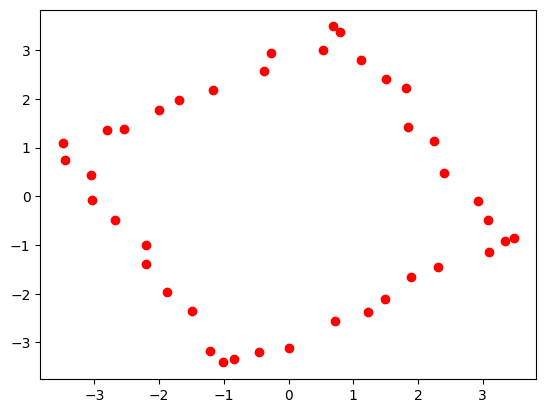

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import random
import seaborn as sns

#generating the random points
# #uncomment on of these
points = generate_random_square_points(5,10 ,0.2,0,0,30)
distance_points = [math.sqrt((x**2) + (y**2)) for x,y in points]
x,y = zip(*points)
# x,y = generate_random_rectangle_with_noise(50,.2, 8,4,105)
# points = list(zip(x,y))
# distance_points = [math.sqrt((x**2) + (y**2)) for x,y in points]

#generating points from an ellipse
# points = generate_random_ellipse_points(50, 8,4,0.2,5,3,math.pi/3)[1]
# x,y = zip(*points)
# distance_points = [math.sqrt((x**2) + (y**2)) for x,y in points]


#generating points from a circle
# points = generate_circle_coordinates_shifted(5, 50,0.2,3, 2)[1]
# x,y = zip(*points)
# distance_points = [math.sqrt((x**2) + (y**2)) for x,y in points]

#fitting data to a square
angle_s,length, error = best_rotated_square(points)
angle_s = math.radians(angle_s)
print(error)
if angle_s > math.pi:
  angle_s = angle_s - (2*math.pi)
#fitting data to a circle
x0_c,y0_c,rad_1 = fit_circle(x,y)
sum = 0
for x_,y_ in points:
  sum += math.sqrt((x_-x0_c)**2 + (y_-y0_c)**2)
print(sum)
print("Circle Radius")
print(rad_1)
#fitting data to a rectangle
base, height, resid, angle_r = find_best_rectangle(x,y)
print(resid)
#fitting data to an ellipse
coeffs = fit_ellipse(np.array(x), np.array(y))

x0_e, y0_e, rad_a, rad_b, e, angle_e = cart_to_pol(coeffs)
print("Ellipse Values: rad_a, rad_b, angle")
print(rad_a, rad_b,angle_e)

#list of radians for each of the points
rad_lst = [math.atan2(y,x) for x,y in points]


rad_lst_r = []
rad_lst_s = []
rad_lst_e = []
for rad in rad_lst:
  if rad + angle_r > (-math.pi) and rad +angle_r < math.pi:
    rad_lst_r.append(rad+angle_r)
  elif rad + angle_r < -math.pi:
    rad_lst_r.append(rad+angle_r + (2*math.pi))
  elif rad + angle_r > math.pi:
    rad_lst_r.append(rad+angle_r -(2*math.pi))
  if rad +angle_s > (-math.pi) and rad+ angle_s < math.pi:
    rad_lst_s.append(rad+angle_s)
  elif rad + angle_s < -math.pi:
    rad_lst_s.append(rad+angle_s + (2*math.pi))
  elif rad + angle_s > math.pi:
    rad_lst_s.append(rad+angle_s - (2*math.pi))
  if rad -angle_e > (-math.pi) and rad- angle_e < math.pi:
    rad_lst_e.append(rad-angle_e)
  elif rad - angle_e < -math.pi:
    rad_lst_e.append(rad-angle_e + (2*math.pi))
  elif rad - angle_e > math.pi:
    rad_lst_e.append(rad-angle_e - (2*math.pi))



#points list for circle points
circle_points = gen_pnts_for_circle(rad_lst,rad_1)

#points list for square points
square_points = gen_pnts_for_rect(rad_lst_s,length,length)

rectangle_points = gen_pnts_for_rect(rad_lst_r,base,height)

ellipse_points = gen_pnts_for_ellipse(rad_lst_e,rad_a,rad_b)

# print(circle_points)
# print(square_points)
# print(rectangle_points)
# print(distance_points)
# print(ellipse_points)

distance_points_er = [(x-x0_e,y-y0_e) for x,y in points]
distance_points_cs = [(x-x0_c,y-y0_c) for x,y in points]
distance_points_er = [math.sqrt((x**2) + (y**2)) for x,y in distance_points_er]
distance_points_cs = [math.sqrt((x**2) + (y**2)) for x,y in distance_points_cs]


similarity_c = finding_similarity_of_graphs(distance_points_cs, circle_points)
print("Circle Similarity: ")
print(similarity_c)



similarity_r = finding_similarity_of_graphs(distance_points_er, rectangle_points)
print("Rectangle Similarity: ")
print(similarity_r)


similarity_e = finding_similarity_of_graphs(distance_points_er, ellipse_points)
print("Ellipse Similarity: ")
print(similarity_e)

similarity_s = finding_similarity_of_graphs(distance_points_cs, square_points)
print("Square Similarity: ")
print(similarity_s)
# degree_lst = [rad*180/math.pi for rad in rad_lst]
# print(degree_lst)

plt.scatter(x,y, color = "red")
#plot shapes on this plot


In [ ]:
print(angle_s)
print(angle_r)
print(angle_e)

-0.5131268000862166
0.7320268373300357
2.0970021198025295


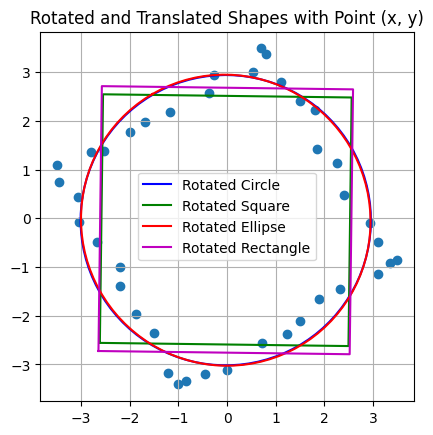

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math


# Define the rotate function
def rotate_point(x, y, angle):
  '''
  Taking in a point and rotating it by an angle

  Args:
    x (float): x-coordinate of the point
    y (float): y-coordinate of the point
    angle (float): angle in radians

  Returns:
    x_rot (float): x-coordinate of the rotated point
    y_rot (float): y-coordinate of the rotated point
  '''
    # Rotate a point (x, y) by an angle in radians
    x_rot = x * np.cos(angle) - y * np.sin(angle)
    y_rot = x * np.sin(angle) + y * np.cos(angle)
    return x_rot, y_rot


def plot_shapes_with_rotation(angle_rectangle, angle_ellipse, square_side, circle_radius, e_rada, e_radb, r_width, r_height, x_pnts,y_pnts, x_shift_s, y_shift_s,x_shift_e, y_shift_e):
  '''
  Plotting a fitted circle, square, ellipse, and rectangle
  with rotation and translation on top of a given set of points

  Args:
    angle_rectangle (float): angle in radians for the rectangle
    angle_ellipse (float): angle in radians for the ellipse
    square_side (float): side length of the square
    circle_radius (float): radius of the circle
    e_rada (float): semi-major axis of the ellipse
    e_radb (float): semi-minor axis of the ellipse
    r_width (float): width of the rectangle
    r_height (float): height of the rectangle
    x_pnts (list): list of x-coordinates of the points
    y_pnts (list): list of y-coordinates of the points
    x_shift_s (float): x-coordinate of the shift for the square
    y_shift_s (float): y-coordinate of the shift for the square
    x_shift_e (float): x-coordinate of the shift for the ellipse
    y_shift_e (float): y-coordinate of the shift for the ellipse

  Returns:
    None
  '''
    fig, ax = plt.subplots()

    num_points = 100
    t = np.linspace(0, 2 * np.pi, num_points)

    # 1. Circle (radius)
    x_circle = circle_radius * np.cos(t)
    y_circle = circle_radius * np.sin(t)

    # Rotate circle points and then shift by (x_shift, y_shift)
    x_circle_rot, y_circle_rot = zip(*[rotate_point(x, y, angle_rectangle) for x, y in zip(x_circle, y_circle)])
    x_circle_rot = np.array(x_circle_rot) + x_shift_s
    y_circle_rot = np.array(y_circle_rot) + y_shift_s
    ax.plot(x_circle_rot, y_circle_rot, label="Rotated Circle", color='b')

    # 2. Square (side length square_side)
    square = np.array([[-square_side / 2, -square_side / 2],
                       [square_side / 2, -square_side / 2],
                       [square_side / 2, square_side / 2],
                       [-square_side / 2, square_side / 2],
                       [-square_side / 2, -square_side / 2]])  # 4 corners
    square_rot = np.array([rotate_point(x, y, angle_rectangle) for x, y in square])
    square_rot[:, 0] += x_shift_s  # Shift by x
    square_rot[:, 1] += y_shift_s  # Shift by y
    ax.plot(square_rot[:, 0], square_rot[:, 1], label="Rotated Square", color='g')

    # 3. Ellipse (semi-major axis e_rada, semi-minor axis e_radb)
    x_ellipse = e_rada * np.cos(t)
    y_ellipse = e_radb * np.sin(t)

    # Rotate ellipse points and then shift by (x_shift, y_shift)
    x_ellipse_rot, y_ellipse_rot = zip(*[rotate_point(x, y, angle_ellipse) for x, y in zip(x_ellipse, y_ellipse)])
    x_ellipse_rot = np.array(x_ellipse_rot) + x_shift_e
    y_ellipse_rot = np.array(y_ellipse_rot) + y_shift_e
    ax.plot(x_ellipse_rot, y_ellipse_rot, label="Rotated Ellipse", color='r')

    # 4. Rectangle (width r_width, height r_height)
    rectangle = np.array([[-r_width / 2, -r_height / 2],
                          [r_width / 2, -r_height / 2],
                          [r_width / 2, r_height / 2],
                          [-r_width / 2, r_height / 2],
                          [-r_width / 2, -r_height / 2]])  # 4 corners
    rectangle_rot = np.array([rotate_point(x, y, angle_rectangle) for x, y in rectangle])
    rectangle_rot[:, 0] += x_shift_e  # Shift by x
    rectangle_rot[:, 1] += y_shift_e  # Shift by y
    ax.plot(rectangle_rot[:, 0], rectangle_rot[:, 1], label="Rotated Rectangle", color='m')

    # # Plot the point (x, y) you want to display
    # ax.scatter(x_shift, y_shift, color='k', label='Shifted Point')

    # Formatting the plot
    ax.set_aspect('equal', 'box')
    ax.set_title("Rotated and Translated Shapes with Point (x, y)")
    ax.legend()
    ax.grid(True)
    plt.scatter(x_pnts,y_pnts)
    plt.show()

# # Example values for shapes and rotation
# rotation_angle = np.pi / 3  # 60 degrees
# square_side = 2
# circle_radius = 1
# e_rada = 2  # semi-major axis of the ellipse
# e_radb = 1  # semi-minor axis of the ellipse
# r_width = 3  # rectangle width
# r_height = 1  # rectangle height
# x_shift = 3  # Shift in x-direction (for point and shapes)
# y_shift = 2  # Shift in y-direction (for point and shapes)

# Plot the shapes with rotation and translation
plot_shapes_with_rotation( -math.radians(angle_r), angle_e, length, rad_1, rad_a, rad_b, base, height, x, y, x0_c, y0_c, x0_e, y0_e)






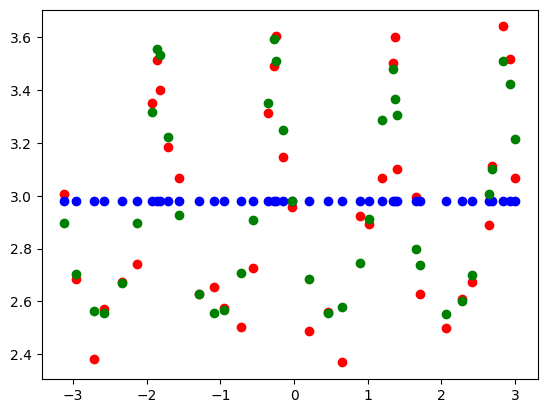

In [ ]:
plt.scatter(rad_lst,distance_points_cs, color = "red" )
plt.scatter(rad_lst, circle_points, color= "blue")
plt.scatter(rad_lst, square_points, color = "green")
# plt.scatter(rad_lst, rectangle_points, color = "yellow")
# plt.scatter(rad_lst, ellipse_points, color = "purple")
plt.show()

In [ ]:
def find_polygon_values(points):
  '''
  Given a set of points, this function analyzes them using

  ######NEED TO FINISH##########
  '''
  x = [x for x,y in points]
  y = [y for x,y in points]
  rad_lst = [math.atan2(y,x) for x,y in points]
  coeffs = fit_ellipse(np.array(x), np.array(y))
  x0_e, y0_e, rad_a, rad_b, e, angle_e = cart_to_pol(coeffs)
  x0_r,y0_r,rad_1 = fit_circle(x,y)
  x_shift_s = [x - x0_r for x in x]
  y_shift_s = [y - y0_r for y in y]
  x_shift_e = [x - x0_e for x in x]
  y_shift_e = [y - y0_e for y in y]
  points_shifted = list(zip(x_shift_s,y_shift_s))
  points_shifted_e = list(zip(x_shift_e,y_shift_e))
  angle_s,length, error = best_rotated_square(points_shifted)
  # plt.scatter(x_shift_e,y_shift_e)
  # plt.show()
  base, height, resid, angle_r = find_best_rectangle(x_shift_e,y_shift_e)
  distance_points_er = [(x-x0_e,y-y0_e) for x,y in points]
  distance_points_cs = [(x-x0_r,y-y0_r) for x,y in points]
  distance_points_er = [math.sqrt((x**2) + (y**2)) for x,y in distance_points_er]
  distance_points_cs = [math.sqrt((x**2) + (y**2)) for x,y in distance_points_cs]
  def polygon_square(points):

    # num_min = find_num_mins(error)
    rad_lst_s = []
    for rad in rad_lst:
      if rad +angle_s > (-math.pi) and rad+ angle_s < math.pi:
        rad_lst_s.append(rad+angle_s)
      elif rad + angle_s < -math.pi:
        rad_lst_s.append(rad+angle_s + (2*math.pi))
      elif rad + angle_s > math.pi:
        rad_lst_s.append(rad+angle_s - (2*math.pi))

    square_points = gen_pnts_for_rect(rad_lst_s,length,length)
    similarity_s = finding_similarity_of_graphs(distance_points_cs, square_points)
    return  error, similarity_s[1]

  def polygon_circle(points):
      # Generate points for the fitted circle
      circle_points = gen_pnts_for_circle(rad_lst, rad_1)
      similarity_c = finding_similarity_of_graphs(distance_points_cs, circle_points)

      # Calculate the residual sum for the circle
      sum_r = 0
      for x_, y_ in points:
          # Calculate the distance between each point and the circle center
          dist_to_center = math.sqrt((x_) ** 2 + (y_) ** 2)
          # Residual: the difference between the distance to the center and the radius
          sum_r += abs(dist_to_center - rad_1)

      return sum_r, similarity_c[1]

  # def polygon_ellipse(points):
  #   x = [x for x,y in points]
  #   y = [y for x,y in points]
  #   coeffs = fit_ellipse(np.array(x), np.array(y))
  #   x0, y0, rad_a, rad_b, e, angle_e = cart_to_pol(coeffs)
  #   x_rotated = [x*math.cos(angle_e) - y*math.sin(angle_e) for x,y in points]
  #   y_rotated = [x*math.sin(angle_e) + y*math.cos(angle_e) for x,y in points]
  #   points_rotated = list(zip(x_rotated,y_rotated))
  #   dist_tot = 0
  #   for x,y in points:
  #     dist = closest_distance_to_ellipse(x,y,rad_a,rad_b)
  #     # theta = math.atan((rad_b*y)/(rad_a*x))
  #     # dist = math.sqrt((x-rad_a*math.cos(theta))**2 + (y-rad_b*math.sin(theta))**2)
  #     dist_tot += dist
  #   rad_lst_e = []
  #   for rad in rad_lst:
  #     if rad -angle_e > (-math.pi) and rad- angle_e < math.pi:
  #       rad_lst_e.append(rad-angle_e)
  #     elif rad - angle_e < -math.pi:
  #       rad_lst_e.append(rad-angle_e + (2*math.pi))
  #     elif rad - angle_e > math.pi:
  #       rad_lst_e.append(rad-angle_e - (2*math.pi))
  #   ellipse_points = gen_pnts_for_ellipse(rad_lst_e,rad_a,rad_b)
  #   similarity_e = finding_similarity_of_graphs(distance_points_er, ellipse_points)
  #   if max(rad_a,rad_b)/min(rad_a,rad_b) > 1.26:

  #     rad_val = 0
  #   else:
  #     rad_val = 1

  #   return dist_tot, similarity_e[0], similarity_e[1], rad_val


  def polygon_ellipse(points):
      # Rotate points based on the ellipse angle
      x_rotated = [x * math.cos(-angle_e) - y * math.sin(-angle_e) for x, y in points]
      y_rotated = [x * math.sin(-angle_e) + y * math.cos(-angle_e) for x, y in points]
      rot_points = list(zip(x_rotated, y_rotated))

      # Calculate the distance to the ellipse for each rotated point
      # Translate points based on the ellipse center
      # points_rotated_translated = [(x - x0_e, y - y0_e) for x, y in zip(x_rotated, y_rotated)]

      # Visualize the rotated and translated points to verify the origin shift
      x_fnl = [x for x in x_rotated]
      y_fnl = [y for y in y_rotated]
      # plt.scatter(x_fnl, y_fnl, color='red', label='Transformed Points')
      # plt.axhline(0, color='black',linewidth=1)
      # plt.axvline(0, color='black',linewidth=1)
      # plt.title("Transformed Points Around the Origin")
      # plt.show()

      # Calculate the residual sum for the ellipse (optional debug step)
      dist_tot = 0
      for x, y in rot_points:
          dist = closest_distance_to_ellipse(x, y, rad_a, rad_b)  # Assuming the center is at the origin now
          dist_tot += dist

      # Generate ellipse points and check similarity (optional step)
      rad_lst_e = []
      for rad in rad_lst:
          if rad - angle_e > -math.pi and rad - angle_e < math.pi:
              rad_lst_e.append(rad - angle_e)
          elif rad - angle_e < -math.pi:
              rad_lst_e.append(rad - angle_e + 2 * math.pi)
          elif rad - angle_e > math.pi:
              rad_lst_e.append(rad - angle_e - 2 * math.pi)

      ellipse_points = gen_pnts_for_ellipse(rad_lst_e, rad_a, rad_b)
      similarity_e = finding_similarity_of_graphs(distance_points_er, ellipse_points)

      # Determine whether the ellipse is circular or elongated
      if max(rad_a, rad_b) / min(rad_a, rad_b) > 1.1:
          rad_val = 0
      else:
          rad_val = 1

      return dist_tot,similarity_e[1], rad_val



  def polygon_rectangle(points):
    rad_lst_r = []
    for rad in rad_lst:
      if rad + angle_r > (-math.pi) and rad +angle_r < math.pi:
        rad_lst_r.append(rad+angle_r)
      elif rad + angle_r < -math.pi:
        rad_lst_r.append(rad+angle_r + (2*math.pi))
      elif rad + angle_r > math.pi:
        rad_lst_r.append(rad+angle_r -(2*math.pi))
    rectangle_points = gen_pnts_for_rect(rad_lst_r,base,height)
    similarity_r = finding_similarity_of_graphs(distance_points_er, rectangle_points)
    rot_x = [x*math.cos(angle_r) - y*math.sin(angle_r) for x,y in points]
    rot_y = [x*math.sin(angle_r) + y*math.cos(angle_r) for x,y in points]
    res = total_residual_1(base,height, rot_x,rot_y)
    # sum_error = sum(abs(er) for er in res)
    # num_min = find_num_mins(res)
    if max(base,height)/min(base,height) > 1.1:
      base_val = 0
    else:
      base_val = 1
    return resid, similarity_r[1], base_val




  return ["square", polygon_square(points)],["circle", polygon_circle(points_shifted)],["ellipse", polygon_ellipse(points_shifted_e)],["rectangle", polygon_rectangle(points)]


NEED TO ADD THE ELLIPSE

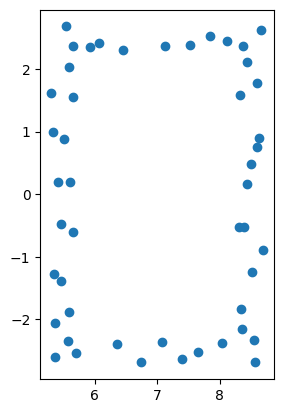

<ipython-input-1-5c60ae635784>:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ellipse_x = rad_a * math.cos(theta)
<ipython-input-1-5c60ae635784>:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ellipse_y = rad_b * math.sin(theta)
<ipython-input-1-5c60ae635784>:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ellipse_x = rad_a * math.cos(theta)
<ipython-input-1-5c60ae635784>:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated,

In [ ]:
points_s = generate_random_square_points(3, 12,0.2, 2,-2,250)
points_e = generate_random_ellipse_points(50, 6,4,0.2,1,-6,-math.pi/3)[1]
xr,yr = generate_random_rectangle_with_noise(50,.2, 5,3,0,7,270)
points_r = list(zip(xr,yr))
points_c = generate_circle_coordinates_shifted(4,50,.2, -80,3)[1]

polygon_s = find_polygon_values(points_s)
polygon_e = find_polygon_values(points_e)
polygon_r = find_polygon_values(points_r)
polygon_c = find_polygon_values(points_c)


In [ ]:
print(polygon_s)
print(polygon_e)
print(polygon_r)
print(polygon_c)

(['square', (4.17240346335469, 2.12562883751671)], ['circle', (8.308210609840089, 1.4900393643299434)], ['ellipse', (8.352866710001694, 1.4796311407369749, 1)], ['rectangle', (11.730137931034488, 2.115789315501838, 1)])
(['square', (30.43566336221391, 5.47854655064731)], ['circle', (37.18595947815348, 6.144439030566786)], ['ellipse', (19.61874673054581, 4.8614177478611715, 0)], ['rectangle', (22.22999999999999, 6.467003240005156, 0)])
(['square', (18.147707368663205, 4.197890608289999)], ['circle', (19.515457627953907, 3.3986729694669067)], ['ellipse', (11.263582020241225, 4.179054488684979, 0)], ['rectangle', (5.065532823840502, 5.980341031379577, 0)])
(['square', (16.337933263937536, 2.21133943966718)], ['circle', (11.232160498035771, 2.0613683212485743)], ['ellipse', (11.195809737188208, 2.0802032625439053, 1)], ['rectangle', (16.550000000000036, 5.6390871479170945, 1)])


In [ ]:
def cosine_sim(v1,v2):
  '''
  This function calculates the cosine similarity of two vectors

  Args:
    v1 (list): first vector
    v2 (list): second vector

  Returns:
    (float) cosine similarity of the two vectors
  '''
  dot_prod = 0
  mag1 = 0
  mag2 = 0
  for i in range(len(v1)):
    dot_prod += v1[i]*v2[i]
    mag1 += v1[i]**2
    mag2 += v2[i]**2
  mag1 = math.sqrt(mag1)
  mag2 = math.sqrt(mag2)
  return dot_prod/(mag1*mag2)

def euc_dist(v1,v2):
  '''
  This function calculates the euclidean distance between two vectors

  Args:
    v1 (list): first vector
    v2 (list): second vector

  Returns:
    (float) euclidean distance between the two vectors
  '''
  dist = 0
  for i in range(len(v1)):
    dist += (v1[i]-v2[i])**2
  return math.sqrt(dist)

def give_best_shape_plus_sim(polygon_v):
  '''
  Given the polygon values, this function compares them to the optimal
  polygon values using euclidean distance to determine which shape
  best fits the data

  Args:
    polygon_v (list): list of polygon values

  Returns:
    (tuple): best shape and similarity value
  '''
  shape_d = {"square": [0,0], "circle": [0,0], "ellipse": [0,0,0], "rectangle": [0,0,0]}

  best_dis = float('inf')
  best_shape = ""
  for shape, val in polygon_v:
    dist = euc_dist(val, shape_d[shape])
    if shape == "ellipse" or shape == "rectangle":
      if val[2] == 1:
        continue
    if dist < best_dis:
      best_dis = dist
      best_shape = shape
  return best_shape, dist

print(give_best_shape_plus_sim(polygon_s))
print(give_best_shape_plus_sim(polygon_e))
print(give_best_shape_plus_sim(polygon_r))
print(give_best_shape_plus_sim(polygon_c))




('square', 11.961300109464933)
('ellipse', 23.15156648925158)
('rectangle', 7.837352974123832)
('circle', 17.512903924301217)


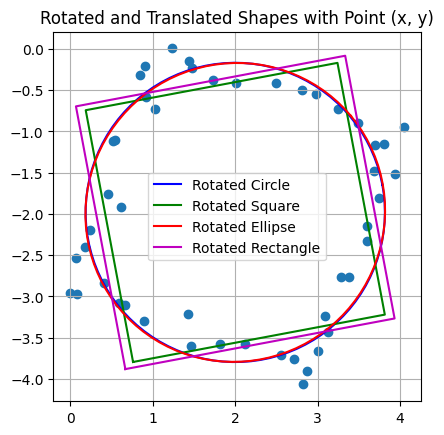

In [ ]:
x_s = [x for x,y in points_s]
y_s = [y for x,y in points_s]
coeffs = fit_ellipse(np.array(x_s), np.array(y_s))
x0_c, y0_c, rad_1 = fit_circle(x_s,y_s)
points_s_shifted = [(x-x0_c,y-y0_c) for x,y in points_s]
angle_s,length, error = best_rotated_square(points_s_shifted)
x0, y0, rad_a, rad_b, e, angle_e = cart_to_pol(coeffs)
x_r_shift = [x-x0_c for x in x_s]
y_r_shift = [y-y0_c for y in y_s]
base, height, resid, angle_r = find_best_rectangle(x_r_shift,y_r_shift)
plot_shapes_with_rotation( -angle_r, angle_e, length, rad_1, rad_a, rad_b, base, height, x_s, y_s, x0_c, y0_c, x0, y0)

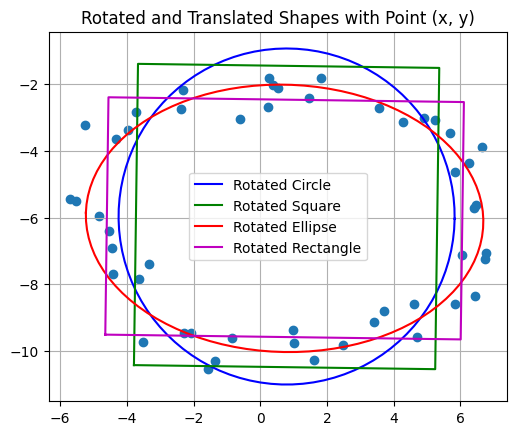

In [ ]:
x_e = [x for x,y in points_e]
y_e = [y for x,y in points_e]
coeffs = fit_ellipse(np.array(x_e), np.array(y_e))
x0_c, y0_c, rad_1 = fit_circle(x_e,y_e)
points_e_shifted = [(x-x0_c,y-y0_c) for x,y in points_e]
angle_s,length, error = best_rotated_square(points_e_shifted)
x0, y0, rad_a, rad_b, e, angle_e = cart_to_pol(coeffs)
x_e_shift = [x-x0_c for x in x_e]
y_e_shift = [y-y0_c for y in y_e]
base, height, resid, angle_r = find_best_rectangle(x_e_shift,y_e_shift)

plot_shapes_with_rotation( -angle_r, angle_e, length, rad_1, rad_a, rad_b, base, height, x_e, y_e, x0_c, y0_c, x0, y0)

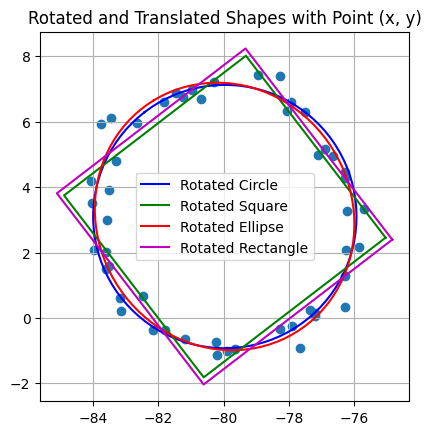

In [ ]:
xc = [x for x,y in points_c]
yc = [y for x,y in points_c]
coeffs = fit_ellipse(np.array(xc), np.array(yc))
x0_c, y0_c, rad_1 = fit_circle(xc,yc)
points_c_shifted = [(x-x0_c,y-y0_c) for x,y in points_c]
angle_s,length, error = best_rotated_square(points_c_shifted)
x0, y0, rad_a, rad_b, e, angle_e = cart_to_pol(coeffs)
x_r_shift = [x-x0_c for x in xc]
y_r_shift = [y-y0_c for y in yc]
base, height, resid, angle_r = find_best_rectangle(x_r_shift,y_r_shift)

plot_shapes_with_rotation( -angle_r, angle_e, length, rad_1, rad_a, rad_b, base, height, xc, yc, x0_c, y0_c, x0, y0)

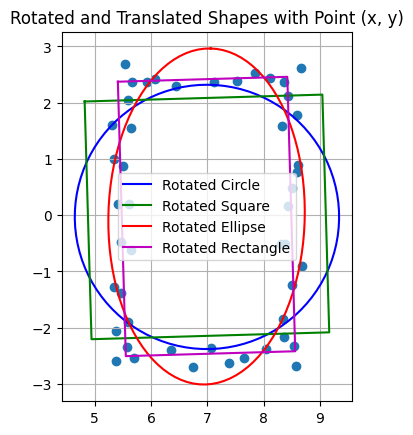

In [ ]:
x_r = [x for x,y in points_r]
y_r = [y for x,y in points_r]
coeffs = fit_ellipse(np.array(x_r), np.array(y_r))
x0_c, y0_c, rad_1 = fit_circle(x_r,y_r)
points_r_shifted = [(x-x0_c,y-y0_c) for x,y in points_r]
angle_s,length, error = best_rotated_square(points_r_shifted)
x0, y0, rad_a, rad_b, e, angle_e = cart_to_pol(coeffs)
x_r_shift = [x-x0_c for x in x_r]
y_r_shift = [y-y0_c for y in y_r]
base, height, resid, angle_r = find_best_rectangle(x_r_shift,y_r_shift)
plot_shapes_with_rotation( angle_r, angle_e, length, rad_1, rad_a, rad_b, base, height, x_r, y_r, x0_c, y0_c, x0, y0)

Writing a function to randomly generate points for a randomly given shape

In [ ]:
def generate_points_rand_shape():
  '''
  This function generates points for a randomly given shape

  Returns:
    (tuple): shape and points
  '''
  d = {1: "square", 2: "circle", 3: "ellipse", 4: "rectangle"}
  shape = random.randint(1,4)
  rand_x_shift = random.uniform(-10,10)
  rand_y_shift = random.uniform(-10,10)
  rand_angle = random.uniform(-180,180)
  if shape == 1:
    rand_length = random.uniform(1, 10)
    return "square", generate_random_square_points(rand_length, 12,0.2, rand_x_shift, rand_y_shift, math.radians(rand_angle))
  elif shape == 2:
    rand_rad = random.uniform(1,10)
    return "circle", generate_circle_coordinates_shifted(rand_rad, 50, 0.2,rand_x_shift, rand_y_shift)[1]
  elif shape == 3:
    rand_rad_a = random.uniform(1,10)
    rand_rad_b = random.uniform(1,10)
    if max(rand_rad_a, rand_rad_b) / min(rad_a, rad_b) < 1.1:
      return "circle", generate_random_ellipse_points(50, rand_rad_a, rand_rad_b, 0.2, rand_x_shift, rand_y_shift, math.radians(rand_angle))[1]
    else:
      return "ellipse", generate_random_ellipse_points(50, rand_rad_a, rand_rad_b, 0.2, rand_x_shift, rand_y_shift, math.radians(rand_angle))[1]
  elif shape == 4:
    rand_base = random.uniform(1,10)
    rand_height = random.uniform(1,10)
    x_r,y_r =  generate_random_rectangle_with_noise(50, 0.2, rand_base, rand_height, rand_x_shift, rand_y_shift, rand_angle)

    if max(rand_base, rand_height) / min(rand_base, rand_height) < 1.1:
      return "square", list(zip(x_r,y_r))
    else:
      return "rectangle", list(zip(x_r,y_r))

#Writing a function to test the predicted shapes
def accuracy():
  '''
  This function tests the accuracy of the predicted shapes by running 100 tests

  Returns:
    (tuple): accuracy and dictionary of correct and incorrect predictions
  '''
  correct_d = {"square": [0,0], "circle": [0,0], "ellipse": [0,0], "rectangle": [0,0]}
  shape_points = [generate_points_rand_shape() for i in range(100)]
  shape = [shape for shape, points in shape_points]
  points = [points for shape, points in shape_points]
  polygon_values = []
  for i,shape_data in enumerate(points):
    print(f"Shape {i}")
    polygon_values.append(find_polygon_values(shape_data))
  predicted_shape = [give_best_shape_plus_sim(poly_v) for poly_v in polygon_values]
  correct = 0
  for i in range(len(predicted_shape)):
    if shape[i] == predicted_shape[i][0]:
      correct += 1
      correct_d[shape[i]][0]+=1
    else:
      correct_d[shape[i]][1]+=1
      print("Actual Shape: " + str(shape[i]))
      print("Predicted Shape: " + str(predicted_shape[i][0]))
      print("Polygon Values")
      print(polygon_values[i])
      plt.scatter([x for x,y in points[i]],[y for x,y in points[i]], color = "red")
      plt.gca().set_aspect('equal', adjustable='box')
      plt.show()

  return correct/len(shape), correct_d

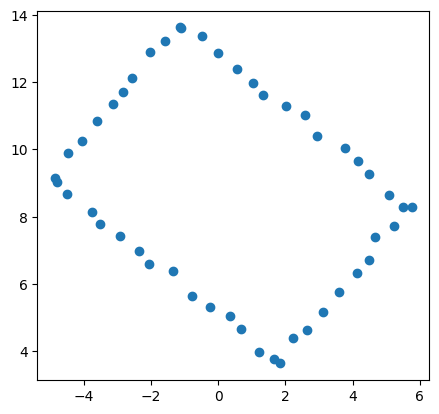

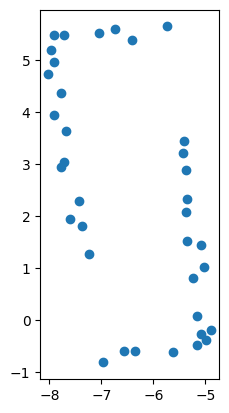

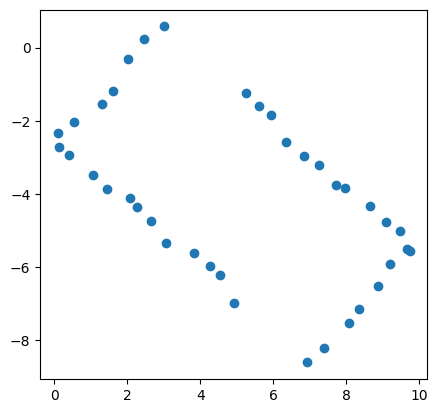

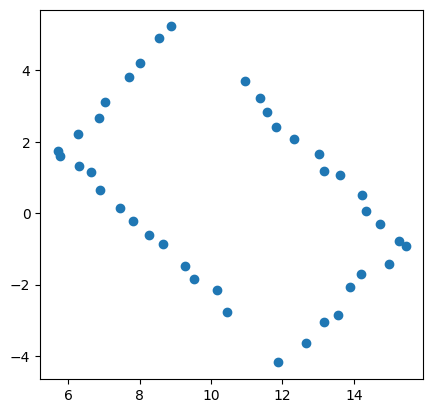

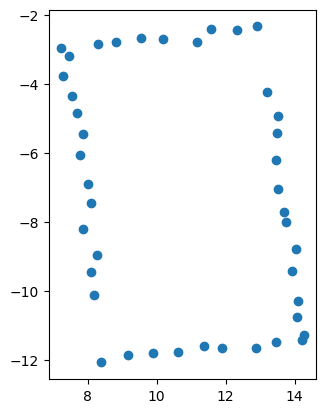

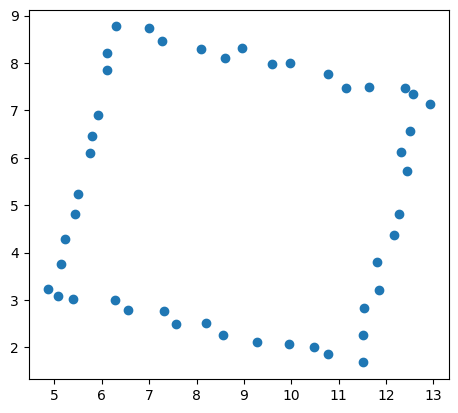

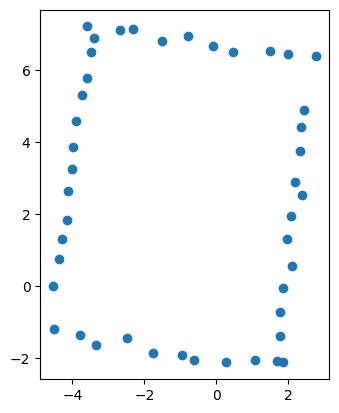

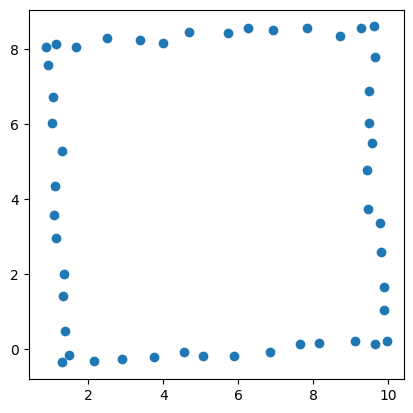

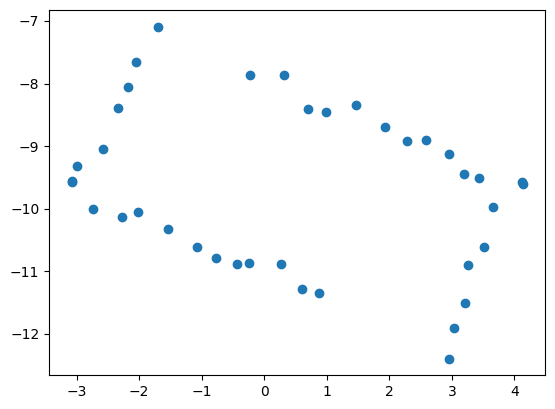

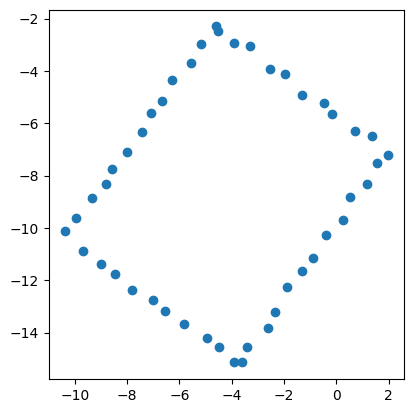

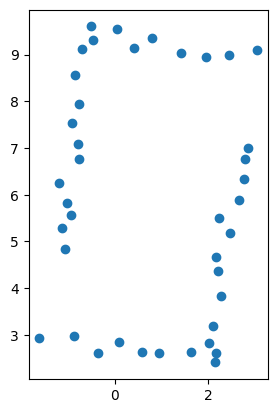

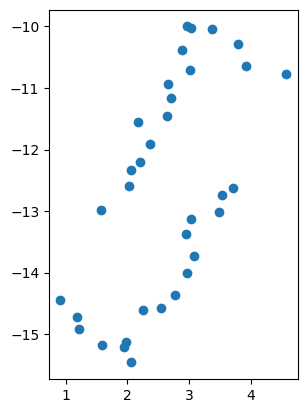

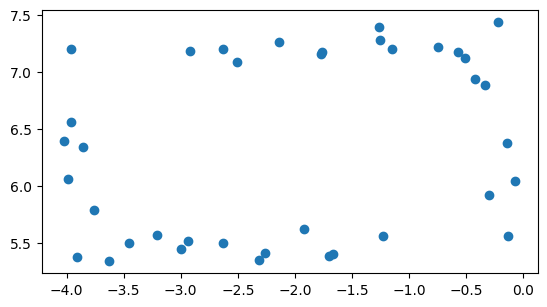

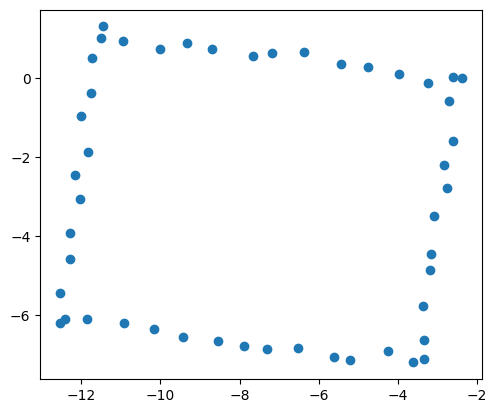

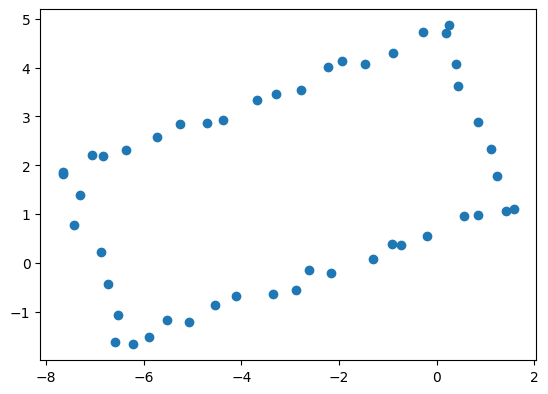

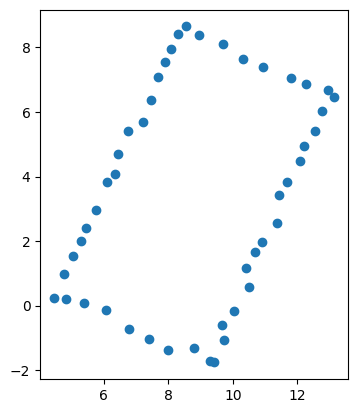

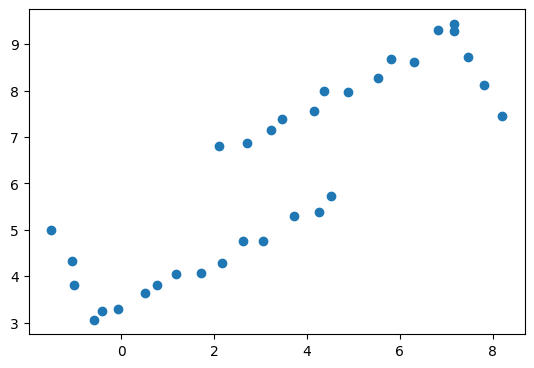

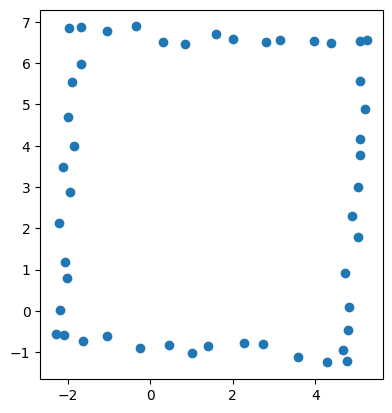

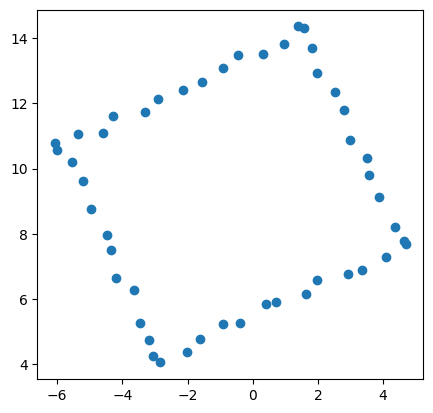

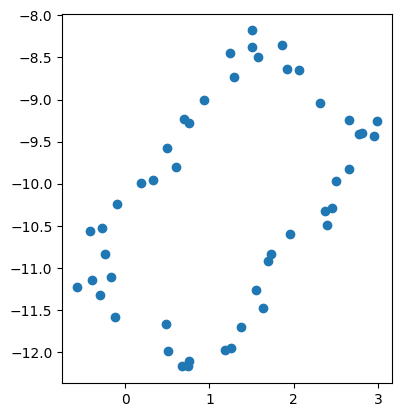

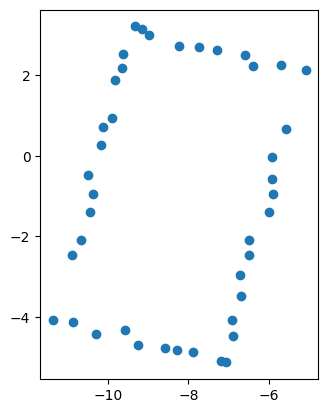

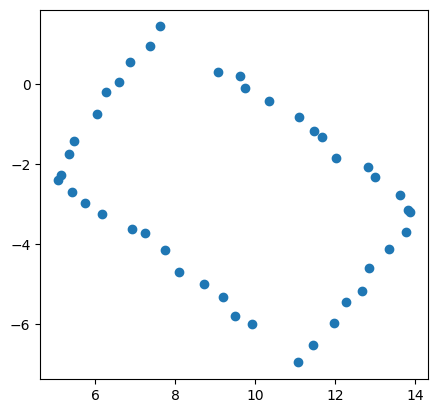

Shape 0


<ipython-input-1-5c60ae635784>:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ellipse_x = rad_a * math.cos(theta)
<ipython-input-1-5c60ae635784>:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ellipse_y = rad_b * math.sin(theta)


Shape 1


<ipython-input-1-5c60ae635784>:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ellipse_x = rad_a * math.cos(theta)
<ipython-input-1-5c60ae635784>:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ellipse_y = rad_b * math.sin(theta)


Shape 2


...

Shape 98


<ipython-input-1-5c60ae635784>:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ellipse_x = rad_a * math.cos(theta)
<ipython-input-1-5c60ae635784>:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ellipse_y = rad_b * math.sin(theta)


Shape 99


<ipython-input-1-5c60ae635784>:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ellipse_x = rad_a * math.cos(theta)
<ipython-input-1-5c60ae635784>:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ellipse_y = rad_b * math.sin(theta)


Actual Shape: rectangle
Predicted Shape: ellipse
Polygon Values
(['square', (21.862444242052018, 4.7563196141723285)], ['circle', (28.615410575574913, 5.170372849422105)], ['ellipse', (5.933212616173137, 6.7778706623806295, 0)], ['rectangle', (6.51, 7.602973460372829, 0)])


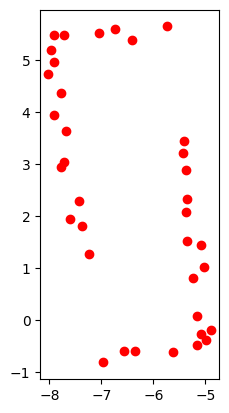

Actual Shape: rectangle
Predicted Shape: ellipse
Polygon Values
(['square', (28.482816051317766, 5.834878738978037)], ['circle', (33.76192325636762, 5.9672118033097625)], ['ellipse', (14.042443105439855, 7.602411716485649, 0)], ['rectangle', (13.829999999999993, 8.149158272565925, 0)])


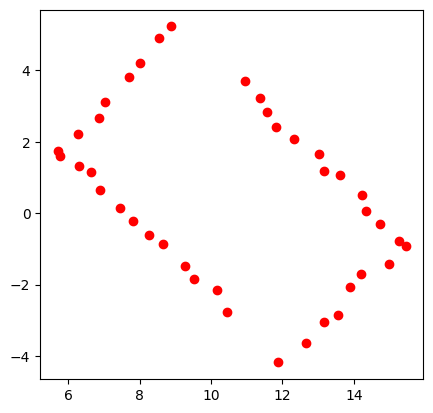

Actual Shape: rectangle
Predicted Shape: ellipse
Polygon Values
(['square', (28.414866494091292, 7.5590639350262485)], ['circle', (32.3884124689225, 5.692497815589367)], ['ellipse', (17.043992949316024, 6.914332782515326, 0)], ['rectangle', (16.801499999999983, 8.568702325390118, 0)])


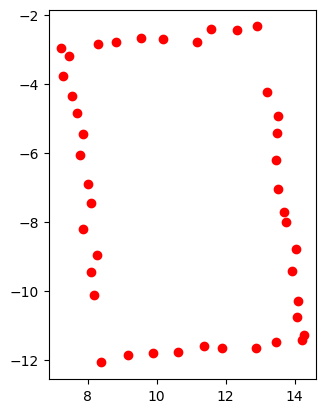

Actual Shape: rectangle
Predicted Shape: square
Polygon Values
(['square', (9.778478746303144, 4.419012283167997)], ['circle', (18.197924917968166, 3.214530345621373)], ['ellipse', (17.34179423953984, 3.451076062458278, 0)], ['rectangle', (17.599999999999994, 4.6520803590208635, 0)])


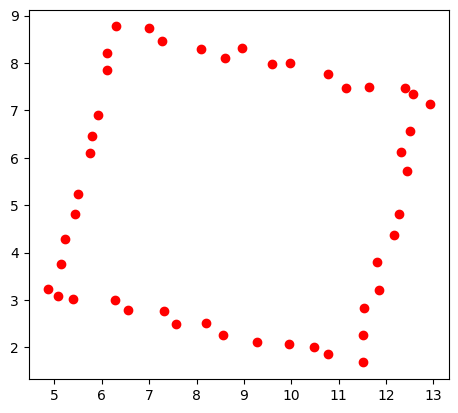

Actual Shape: rectangle
Predicted Shape: ellipse
Polygon Values
(['square', (22.162525777269675, 4.749704884816177)], ['circle', (27.880623864317105, 5.061992005849488)], ['ellipse', (9.201591341298476, 6.236072254702746, 0)], ['rectangle', (9.420726375176296, 8.800730454969527, 0)])


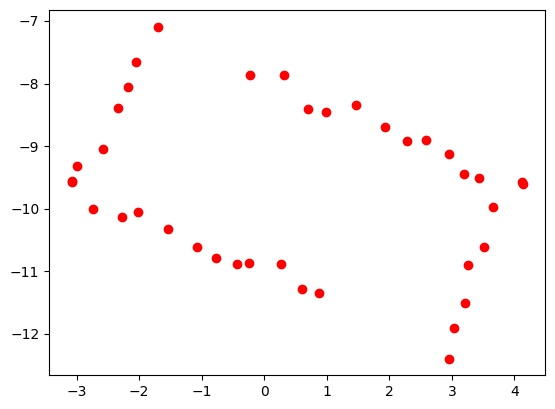

Actual Shape: rectangle
Predicted Shape: ellipse
Polygon Values
(['square', (18.8197825728085, 4.554583082128845)], ['circle', (24.265037326083885, 4.704473448888377)], ['ellipse', (5.684745488745547, 5.780772521877061, 0)], ['rectangle', (5.929999999999998, 5.614051473885224, 0)])


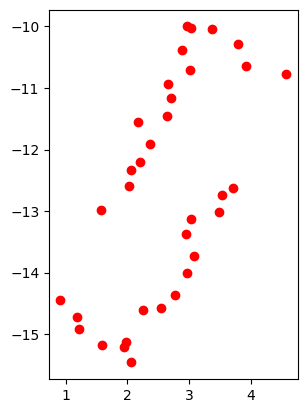

Actual Shape: rectangle
Predicted Shape: ellipse
Polygon Values
(['square', (12.215553803145106, 3.2942059437396205)], ['circle', (15.21679786765908, 2.705408740276348)], ['ellipse', (4.550065559112317, 3.4029183377252807, 0)], ['rectangle', (5.3319117647058905, 4.604523071213586, 0)])


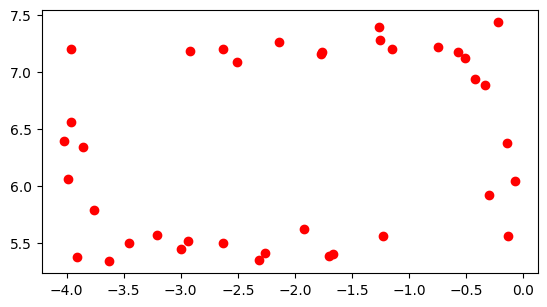

Actual Shape: ellipse
Predicted Shape: circle
Polygon Values
(['square', (32.18290798049103, 8.838654394288493)], ['circle', (31.644166126276073, 5.310667497195745)], ['ellipse', (29.708640871005645, 5.387773156880285, 1)], ['rectangle', (39.33999999999998, 8.117577590001861, 0)])


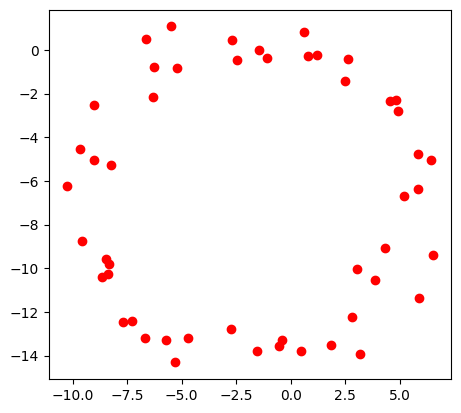

Actual Shape: ellipse
Predicted Shape: rectangle
Polygon Values
(['square', (57.30692749403643, 12.50799928061257)], ['circle', (62.69424932094977, 11.030456771985804)], ['ellipse', (36.96874256872101, 10.63826463024613, 0)], ['rectangle', (35.48142857142861, 11.105215040613741, 0)])


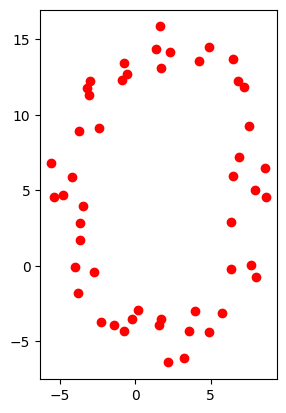

(0.91, {'square': [36, 0], 'circle': [23, 0], 'ellipse': [19, 2], 'rectangle': [13, 7]})


In [ ]:
a = accuracy()

print(a)